24RB1074 半田悠人

## 課題2：グリッドワールド

In [14]:
import numpy as np
import matplotlib.pyplot as plt

### 1:価値反復の実装

In [15]:
G = (3, 3)
gamma = 0.9
S = [(1,1), (1,2), (1,3), (2,1), (2,2), (2,3), (3,1), (3,2), (3,3)]
A = [(1,0), (-1,0), (0,1), (0,-1)]
def f(s, a):
    s_ = (s[0] + a[0], s[1] + a[1])
    if s_ in S:
        return s_
    else:
        return s

def r(s, a, s_):
    if s_ == (3,3):
        return 1
    else:
        return 0
    
def V(k, s):
    if k <= 0:
        return 0
    
    if s == (3,3):
        return 0
    else:
        return max([r(s, a, f(s, a)) + gamma * V(k-1, f(s, a)) for a in A])
    
def d(s):
    return abs(s[0] - 3) + abs(s[1] - 3)

### 2:状態価値の出力

In [16]:
for k in range(1, 8):
    print(f'k={k}')
    for s in S:
        print(f'V({k}, {s}) = {V(k, s)}')
    print()

k=1
V(1, (1, 1)) = 0.0
V(1, (1, 2)) = 0.0
V(1, (1, 3)) = 0.0
V(1, (2, 1)) = 0.0
V(1, (2, 2)) = 0.0
V(1, (2, 3)) = 1.0
V(1, (3, 1)) = 0.0
V(1, (3, 2)) = 1.0
V(1, (3, 3)) = 0

k=2
V(2, (1, 1)) = 0.0
V(2, (1, 2)) = 0.0
V(2, (1, 3)) = 0.9
V(2, (2, 1)) = 0.0
V(2, (2, 2)) = 0.9
V(2, (2, 3)) = 1.0
V(2, (3, 1)) = 0.9
V(2, (3, 2)) = 1.0
V(2, (3, 3)) = 0

k=3
V(3, (1, 1)) = 0.0
V(3, (1, 2)) = 0.81
V(3, (1, 3)) = 0.9
V(3, (2, 1)) = 0.81
V(3, (2, 2)) = 0.9
V(3, (2, 3)) = 1.0
V(3, (3, 1)) = 0.9
V(3, (3, 2)) = 1.0
V(3, (3, 3)) = 0

k=4
V(4, (1, 1)) = 0.7290000000000001
V(4, (1, 2)) = 0.81
V(4, (1, 3)) = 0.9
V(4, (2, 1)) = 0.81
V(4, (2, 2)) = 0.9
V(4, (2, 3)) = 1.0
V(4, (3, 1)) = 0.9
V(4, (3, 2)) = 1.0
V(4, (3, 3)) = 0

k=5
V(5, (1, 1)) = 0.7290000000000001
V(5, (1, 2)) = 0.81
V(5, (1, 3)) = 0.9
V(5, (2, 1)) = 0.81
V(5, (2, 2)) = 0.9
V(5, (2, 3)) = 1.0
V(5, (3, 1)) = 0.9
V(5, (3, 2)) = 1.0
V(5, (3, 3)) = 0

k=6
V(6, (1, 1)) = 0.7290000000000001
V(6, (1, 2)) = 0.81
V(6, (1, 3)) = 0.9
V(6, (2, 1)) = 0.

### $k \geq 4$ から変化がないので、それまででヒートマップ化

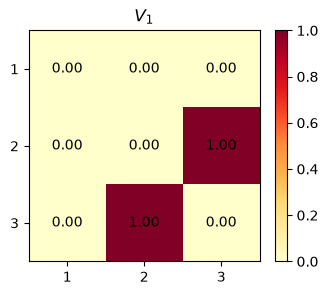

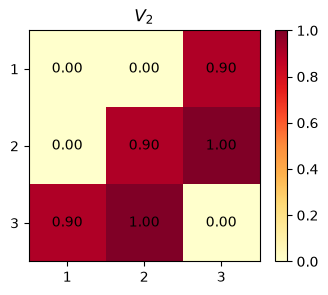

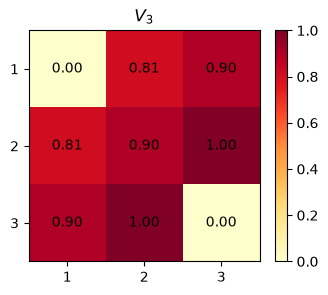

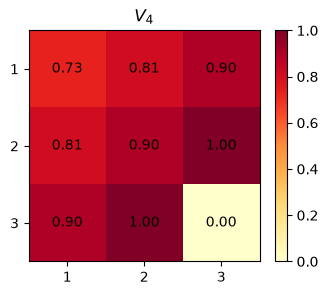

In [17]:
for k in range(1, 5):
    V_k = np.array([
        [V(k, (row, col)) for col in range(1, 4)]
        for row in range(1, 4)
    ])
    
    plt.figure(figsize=(4, 3))
    plt.imshow(V_k, cmap="YlOrRd", vmin=0, vmax=1)

    for row in range(3):
        for col in range(3):
            plt.text(col, row, f"{V_k[row, col]:.2f}",
                     ha="center", va="center")

    plt.title(f"$V_{k}$")
    plt.xticks(range(3), [1, 2, 3])
    plt.yticks(range(3), [1, 2, 3])
    plt.colorbar()
    plt.show()

### 3:収束後の可視化

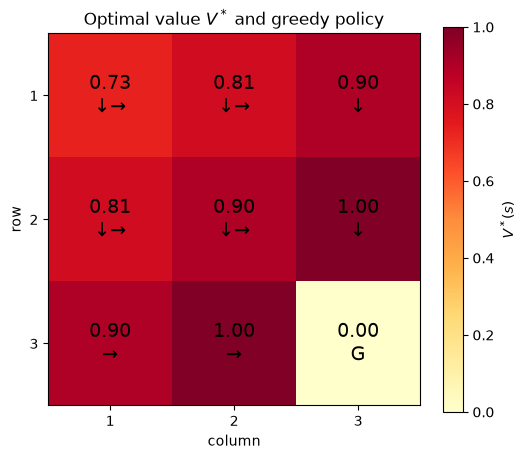

In [18]:
# k = 4 で収束した価値関数を最適価値関数 V* とする
V_star = {s: V(4, s) for s in S}

arrow = {(1, 0): '↓', (-1, 0): '↑', (0, 1): '→', (0, -1): '←'}
policy = {}

# 各状態における最適な行動を決定する
for s in S:
    if s == G:
        policy[s] = 'G'
        continue
    
    # 現在の状態 s において、各行動 a をとったときのQを計算
    q_values = {}
    for a in A:
        next_s = f(s, a)                   
        reward = r(s, a, next_s)            
        q_values[a] = reward + gamma * V_star[next_s]
        
    q_max = max(q_values.values())
    
    best_actions = [arrow[a] for a in A if np.isclose(q_values[a], q_max)]
    policy[s] = ''.join(best_actions)


V_grid = np.array([
    [V_star[(row, col)] for col in range(1, 4)]
    for row in range(1, 4)
])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(V_grid, cmap='YlOrRd', vmin=0, vmax=1)
for row in range(3):
    for col in range(3):
        s = (row + 1, col + 1)
        ax.text(col, row, f'{V_star[s]:.2f}\n{policy[s]}',
                ha='center', va='center', fontsize=14)

ax.set_title(r'Optimal value $V^*$ and greedy policy')
ax.set_xticks(range(3), [1, 2, 3])
ax.set_yticks(range(3), [1, 2, 3])
ax.set_xlabel('column')
ax.set_ylabel('row')
fig.colorbar(im, ax=ax, label=r'$V^*(s)$')
plt.show()

### 4:理論値との一致確認

In [20]:
for s in S:
    if s == G:
        continue
    print(f"V*({s}) = {V_star[s]}")
    print(f"gamma^d-1 = {gamma**(d(s)-1)}")
    if np.isclose(V_star[s], gamma**(d(s)-1)):
        print("一致した")
    print()

V*((1, 1)) = 0.7290000000000001
gamma^d-1 = 0.7290000000000001
一致した

V*((1, 2)) = 0.81
gamma^d-1 = 0.81
一致した

V*((1, 3)) = 0.9
gamma^d-1 = 0.9
一致した

V*((2, 1)) = 0.81
gamma^d-1 = 0.81
一致した

V*((2, 2)) = 0.9
gamma^d-1 = 0.9
一致した

V*((2, 3)) = 1.0
gamma^d-1 = 1.0
一致した

V*((3, 1)) = 0.9
gamma^d-1 = 0.9
一致した

V*((3, 2)) = 1.0
gamma^d-1 = 1.0
一致した



## 観察と考察


#### 観察

反復回数を増やすと、ゴール $(3, 3)$ に近い状態から順に価値が伝播した。$k=1$ ではゴールに隣接する $(2, 3)$ と $(3, 2)$ の価値だけが 1 となり、$k=2, 3, 4$ と増えるにつれて、より離れた状態にも価値が現れた。$k=4$ では最も遠い $(1, 1)$ の価値が 0.729 となり、すべての状態の価値が確定した。$k=5$ 以降は値が変化せず、$V_4=V_5$ であることから、価値関数は $k=4$ で収束したといえる。

収束後のヒートマップでは、ゴールに近い状態ほど価値が高く、ゴールから1手離れた状態は 1、2手離れた状態は 0.9、3手離れた状態は 0.81、4手離れた $(1, 1)$ は 0.729 となった。また、最適方策の矢印はゴールまでの最短経路を示し、下方向と右方向のどちらを選んでも最短距離が同じ状態では、両方の矢印が表示された。
また、ゴールまでの最短距離を $d(s)$ とすると、ゴール以外の状態価値は $V^*(s)=\gamma^{d(s)-1}$ となった。

#### 考察

今回のグリッドでは、ゴールから最も遠い状態までの最短距離が4であるため、4回の更新ですべての状態に報酬の情報が届いたと考えられる。さらに、割引によって遠い状態ほど価値が小さくなるため、貪欲方策は報酬をより早く得られる最短経路を選択しているといえるだろう。